In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [6]:
DATA_PATH = "../data/raw"

customers = pd.read_csv(
    f"{DATA_PATH}/customers.csv"
)

restaurants = pd.read_csv(
    f"{DATA_PATH}/restaurants.csv"
)

orders = pd.read_csv(
    f"{DATA_PATH}/orders.csv",
    parse_dates=["order_timestamp"]
)

deliveries = pd.read_csv(
    f"{DATA_PATH}/deliveries.csv"
)

reviews = pd.read_csv(
    f"{DATA_PATH}/reviews.csv",
    parse_dates=["review_timestamp"]
)

payments = pd.read_csv(
    f"{DATA_PATH}/payments.csv"
)

In [7]:
print("Customers:", customers.shape)
print("Restaurants:", restaurants.shape)
print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Reviews:", reviews.shape)
print("Payments:", payments.shape)

Customers: (10000, 6)
Restaurants: (500, 7)
Orders: (100000, 8)
Deliveries: (90002, 10)
Reviews: (54001, 6)
Payments: (100000, 7)


In [8]:
print("CUSTOMERS")
display(customers.head())

print("\nORDERS")
display(orders.head())

print("\nDELIVERIES")
display(deliveries.head())

print("\nREVIEWS")
display(reviews.head())

print("\nRESTAURANTS")
display(restaurants.head())

CUSTOMERS


,customer_id,age,gender,city,signup_date,membership_type
0,C000001,56,Female,Chennai,2025-05-07,Premium
1,C000002,69,Male,Pune,2026-06-25,Gold
2,C000003,46,Female,Delhi,2025-07-17,Standard
3,C000004,32,Male,Chennai,2026-04-27,Gold
4,C000005,60,Female,Kochi,2025-06-28,Gold



ORDERS


,order_id,customer_id,restaurant_id,order_timestamp,order_amount,item_count,payment_method,order_status
0,O000001,C001469,R00176,2025-06-13 19:00:00,505.66,3,Cash,Completed
1,O000002,C001001,R00213,2025-05-27 21:00:00,601.49,3,UPI,Completed
2,O000003,C002237,R00303,2025-09-29 11:00:00,"1,611.51",6,Wallet,Completed
3,O000004,C000983,R00497,2025-11-19 22:00:00,416.92,2,UPI,Completed
4,O000005,C005138,R00133,2025-11-06 13:00:00,"1,309.67",7,Debit Card,Cancelled



DELIVERIES


,delivery_id,order_id,driver_id,delivery_distance_km,preparation_time_min,delivery_time_min,traffic_condition,weather,tip_amount,delivery_status
0,DL000001,O000001,D00644,5.12,44,52,Low,Cloudy,56.38,Completed
1,DL000002,O000002,D00598,3.28,30,28,Low,Clear,86.60,Completed
2,DL000003,O000003,D00937,2.98,30,19,Low,Cloudy,179.94,Completed
3,DL000004,O000004,D00717,2.02,34,42,Low,Clear,34.17,Completed
4,DL000005,O000007,D00059,5.70,21,56,High,Clear,8.24,Completed



REVIEWS


,review_id,order_id,customer_id,review_rating,review_text,review_timestamp
0,RV000001,O089133,C005079,4,Really happy with the delivery and service.,2025-06-14 16:27:00
1,RV000002,O013863,C004885,5,Really happy with the delivery and service.,2025-06-29 22:47:00
2,RV000003,O059312,C004955,4,"Great experience, the food was delicious.",2025-11-24 12:47:00
3,RV000004,O086506,C000669,3,Average experience. Nothing particularly good ...,2025-09-05 21:42:00
4,RV000005,O073707,C002424,5,Excellent food and smooth delivery.,2026-02-08 10:01:00



RESTAURANTS


,restaurant_id,restaurant_name,city,cuisine,restaurant_rating,avg_prep_time,price_range
0,R00001,"Choudhury, Bakshi and Maharaj",Pune,Desserts,4.35,35,Low
1,R00002,Kapoor and Sons,Bangalore,Healthy,4.08,36,Low
2,R00003,"Chaudry, Chahal and Sami",Ahmedabad,Biryani,3.92,43,Medium
3,R00004,Balan Inc,Jaipur,Fast Food,3.70,32,Low
4,R00005,Kaul PLC,Jaipur,South Indian,3.41,25,High


In [9]:
print("Customers columns:")
print(customers.columns.tolist())

print("\nOrders columns:")
print(orders.columns.tolist())

print("\nDeliveries columns:")
print(deliveries.columns.tolist())

print("\nReviews columns:")
print(reviews.columns.tolist())

print("\nRestaurants columns:")
print(restaurants.columns.tolist())

Customers columns:
['customer_id', 'age', 'gender', 'city', 'signup_date', 'membership_type']

Orders columns:
['order_id', 'customer_id', 'restaurant_id', 'order_timestamp', 'order_amount', 'item_count', 'payment_method', 'order_status']

Deliveries columns:
['delivery_id', 'order_id', 'driver_id', 'delivery_distance_km', 'preparation_time_min', 'delivery_time_min', 'traffic_condition', 'weather', 'tip_amount', 'delivery_status']

Reviews columns:
['review_id', 'order_id', 'customer_id', 'review_rating', 'review_text', 'review_timestamp']

Restaurants columns:
['restaurant_id', 'restaurant_name', 'city', 'cuisine', 'restaurant_rating', 'avg_prep_time', 'price_range']


In [10]:
# Feature 1 - total_orders
completed_orders = orders[
    orders["order_status"] == "Completed"
].copy()

customer_orders = (
    completed_orders
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

In [11]:
# Feature 2 - avg_order_value

customer_aov = (
    completed_orders
    .groupby("customer_id")
    .agg(
        avg_order_value=("order_amount", "mean")
    )
    .reset_index()
)


In [12]:
# Feature 3 - total_spending

customer_spending = (
    completed_orders
    .groupby("customer_id")
    .agg(
        total_spending=("order_amount", "sum")
    )
    .reset_index()
)

In [13]:
# Feature 4 - Order Frequecy (monthy)

completed_orders["order_month"] = (
    completed_orders["order_timestamp"]
    .dt.to_period("M")
)

customer_frequency = (
    completed_orders
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        active_months=("order_month", "nunique")
    )
    .reset_index()
)

customer_frequency["ordering_frequency"] = (
    customer_frequency["total_orders"]
    / customer_frequency["active_months"]
)

In [14]:
# Feature 5 - avg_rating_given

customer_rating = (
    reviews
    .groupby("customer_id")
    .agg(
        avg_rating_given=("review_rating", "mean")
    )
    .reset_index()
)

In [15]:
# Feature 6 - Weekend Orders

completed_orders["is_weekend"] = (
    completed_orders["order_timestamp"]
    .dt.dayofweek >= 5
)

weekend_orders = (
    completed_orders[
        completed_orders["is_weekend"]
    ]
    .groupby("customer_id")
    .agg(
        weekend_orders=("order_id", "nunique")
    )
    .reset_index()
)

In [16]:
# Feature 7 - Late_night_orders

completed_orders["hour"] = (
    completed_orders["order_timestamp"]
    .dt.hour
)

completed_orders["is_late_night"] = (
    (completed_orders["hour"] >= 22) |
    (completed_orders["hour"] < 5)
)

late_night_orders = (
    completed_orders[
        completed_orders["is_late_night"]
    ]
    .groupby("customer_id")
    .agg(
        late_night_orders=("order_id", "nunique")
    )
    .reset_index()
)

In [17]:
# Combinign Features

customer_features = customers[
    ["customer_id"]
].copy()

feature_tables = [
    customer_orders,
    customer_aov,
    customer_spending,
    customer_frequency[
        ["customer_id", "ordering_frequency"]
    ],
    customer_rating,
    weekend_orders,
    late_night_orders
]

for df in feature_tables:
    customer_features = customer_features.merge(
        df,
        on="customer_id",
        how="left"
    )

In [18]:
count_features = [
    "total_orders",
    "total_spending",
    "weekend_orders",
    "late_night_orders"
]

customer_features[count_features] = (
    customer_features[count_features]
    .fillna(0)
)

In [19]:
customer_features["avg_order_value"] = (
    customer_features["avg_order_value"]
    .fillna(0)
)

customer_features["ordering_frequency"] = (
    customer_features["ordering_frequency"]
    .fillna(0)
)

customer_features["avg_rating_given"] = (
    customer_features["avg_rating_given"]
    .fillna(
        reviews["review_rating"].mean()
    )
)

In [20]:
customer_features.head()

,customer_id,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
0,C000001,15.00,963.10,"14,446.47",1.50,3.50,3.00,2.00
1,C000002,7.00,727.93,"5,095.52",1.40,3.00,1.00,2.00
2,C000003,7.00,622.82,"4,359.71",1.17,3.00,3.00,0.00
3,C000004,13.00,942.81,"12,256.58",1.18,3.25,5.00,1.00
4,C000005,7.00,662.28,"4,635.95",1.17,3.40,2.00,2.00


In [21]:
customer_features.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         10000 non-null  str    
 1   total_orders        10000 non-null  float64
 2   avg_order_value     10000 non-null  float64
 3   total_spending      10000 non-null  float64
 4   ordering_frequency  10000 non-null  float64
 5   avg_rating_given    10000 non-null  float64
 6   weekend_orders      10000 non-null  float64
 7   late_night_orders   10000 non-null  float64
dtypes: float64(7), str(1)
memory usage: 693.5 KB


In [22]:
customer_features.isna().sum()

customer_id           0
total_orders          0
avg_order_value       0
total_spending        0
ordering_frequency    0
avg_rating_given      0
weekend_orders        0
late_night_orders     0
dtype: int64

In [23]:
customer_features.describe()

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,9.00,812.85,"7,310.25",1.27,3.42,3.09,1.67
std,2.97,165.18,"2,761.43",0.21,0.56,1.74,1.29
min,0.00,0.00,0.00,0.00,1.00,0.00,0.00
25%,7.00,703.64,"5,352.77",1.12,3.00,2.00,1.00
50%,9.00,809.66,"7,108.58",1.25,3.43,3.00,2.00
75%,11.00,916.36,"9,044.03",1.40,3.80,4.00,2.00
max,22.00,"1,997.57","18,524.59",3.00,5.00,11.00,8.00


In [24]:
customer_features.to_csv(
    "../data/processed/customer_features.csv",
    index=False
)

In [25]:
customer_features[
    [
        "total_orders",
        "avg_order_value",
        "total_spending",
        "ordering_frequency",
        "avg_rating_given",
        "weekend_orders",
        "late_night_orders"
    ]
].corr().round(2)

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
total_orders,1.00,-0.01,0.87,0.46,0.00,0.57,0.43
avg_order_value,-0.01,1.00,0.45,-0.00,0.00,-0.01,-0.02
total_spending,0.87,0.45,1.00,0.40,0.00,0.49,0.37
ordering_frequency,0.46,-0.00,0.40,1.00,0.01,0.26,0.20
avg_rating_given,0.00,0.00,0.00,0.01,1.00,-0.00,0.02
weekend_orders,0.57,-0.01,0.49,0.26,-0.00,1.00,0.25
late_night_orders,0.43,-0.02,0.37,0.20,0.02,0.25,1.00


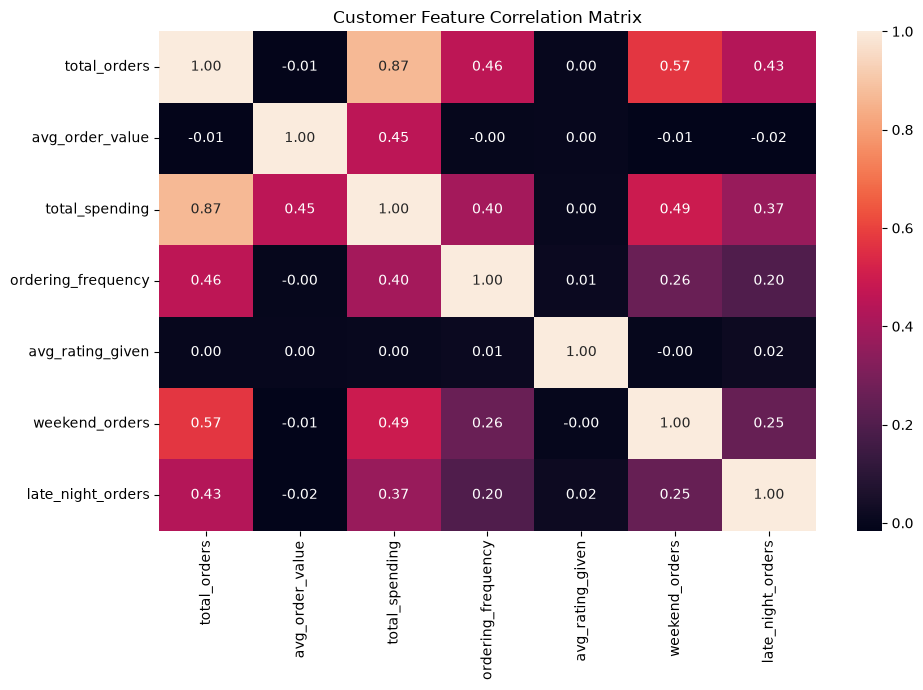

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    customer_features[
        [
            "total_orders",
            "avg_order_value",
            "total_spending",
            "ordering_frequency",
            "avg_rating_given",
            "weekend_orders",
            "late_night_orders"
        ]
    ].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Customer Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [27]:
count_columns = [
    "total_orders",
    "weekend_orders",
    "late_night_orders"
]

customer_features[count_columns] = (
    customer_features[count_columns]
    .astype(int)
)

In [28]:
customer_features.dtypes

customer_id               str
total_orders            int64
avg_order_value       float64
total_spending        float64
ordering_frequency    float64
avg_rating_given      float64
weekend_orders          int64
late_night_orders       int64
dtype: object

In [29]:
# Dropping total spendings
customer_model_data = customer_features[
    [
        "customer_id",
        "total_orders",
        "avg_order_value",
        "ordering_frequency",
        "avg_rating_given",
        "weekend_orders",
        "late_night_orders"
    ]
].copy()

customer_ids = customer_model_data["customer_id"]

X_customer = customer_model_data.drop(
    columns=["customer_id"]
)

X_customer.head()

,total_orders,avg_order_value,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
0,15,963.10,1.50,3.50,3,2
1,7,727.93,1.40,3.00,1,2
2,7,622.82,1.17,3.00,3,0
3,13,942.81,1.18,3.25,5,1
4,7,662.28,1.17,3.40,2,2


# Restaurant Feature Engineering 

In [30]:
# total_orders

restaurant_orders = (
    orders
    .groupby("restaurant_id")
    .agg(
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

In [31]:
# revenue

restaurant_revenue = (
    completed_orders
    .groupby("restaurant_id")
    .agg(
        revenue=("order_amount", "sum")
    )
    .reset_index()
)

In [32]:
# avg_rating

restaurant_reviews = reviews.merge(
    orders[["order_id", "restaurant_id"]],
    on="order_id",
    how="left"
)

restaurant_rating = (
    restaurant_reviews
    .groupby("restaurant_id")
    .agg(
        avg_rating=("review_rating", "mean")
    )
    .reset_index()
)

In [33]:
# avg_preparation_time

restaurant_deliveries = deliveries.merge(
    orders[["order_id", "restaurant_id"]],
    on="order_id",
    how="left"
)

restaurant_prep = (
    restaurant_deliveries
    .groupby("restaurant_id")
    .agg(
        avg_preparation_time=("preparation_time_min", "mean")
    )
    .reset_index()
)

In [34]:
# avg_delivery_time

restaurant_delivery = (
    restaurant_deliveries
    .groupby("restaurant_id")
    .agg(
        avg_delivery_time=("delivery_time_min", "mean")
    )
    .reset_index()
)

In [35]:
# Cancellation Rate

orders["is_cancelled"] = (
    orders["order_status"] == "Cancelled"
).astype(int)

restaurant_cancellation = (
    orders
    .groupby("restaurant_id")
    .agg(
        cancellation_rate=("is_cancelled", "mean")
    )
    .reset_index()
)

restaurant_cancellation["cancellation_rate"] *= 100

In [36]:
restaurant_features = restaurants[
    ["restaurant_id"]
].copy()

restaurant_tables = [
    restaurant_orders,
    restaurant_revenue,
    restaurant_rating,
    restaurant_prep,
    restaurant_cancellation,
    restaurant_delivery
]

for df in restaurant_tables:
    restaurant_features = restaurant_features.merge(
        df,
        on="restaurant_id",
        how="left"
    )

In [37]:
print("REVIEWS")
print(reviews.columns.tolist())

print("\nDELIVERIES")
print(deliveries.columns.tolist())

REVIEWS
['review_id', 'order_id', 'customer_id', 'review_rating', 'review_text', 'review_timestamp']

DELIVERIES
['delivery_id', 'order_id', 'driver_id', 'delivery_distance_km', 'preparation_time_min', 'delivery_time_min', 'traffic_condition', 'weather', 'tip_amount', 'delivery_status']


In [38]:
restaurant_features.head()

,restaurant_id,total_orders,revenue,avg_rating,avg_preparation_time,cancellation_rate,avg_delivery_time
0,R00001,209,"148,583.76",3.41,34.79,6.70,52.99
1,R00002,208,"149,475.28",3.55,35.10,5.77,51.66
2,R00003,199,"141,752.46",3.25,42.71,10.55,56.39
3,R00004,182,"145,040.44",3.56,31.27,6.59,49.96
4,R00005,200,"136,788.24",3.81,24.63,7.50,47.66


In [39]:
# save the data frame

restaurant_features.to_csv(
    "../data/processed/restaurant_features.csv",
    index=False
)

In [40]:
restaurant_features.describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,500.00,200.00,13.37,165.00,190.00,201.00,210.00,243.00
revenue,500.00,"146,205.09","11,751.80","117,637.49","137,797.18","145,754.13","154,749.13","180,060.14"
avg_rating,500.00,3.42,0.41,2.46,3.08,3.46,3.76,4.26
avg_preparation_time,500.00,34.36,14.13,11.86,21.97,33.35,47.16,60.98
cancellation_rate,500.00,6.87,1.83,1.56,5.71,6.81,7.95,12.07
avg_delivery_time,500.00,52.13,7.11,39.14,45.94,51.53,58.12,67.22


# Standard Scalar

In [41]:
customer_features_for_model = [
    "total_orders",
    "avg_order_value",
    "ordering_frequency",
    "avg_rating_given",
    "weekend_orders",
    "late_night_orders"
]

X_customer = customer_features[
    customer_features_for_model
].copy()

X_customer.head()

,total_orders,avg_order_value,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
0,15,963.10,1.50,3.50,3,2
1,7,727.93,1.40,3.00,1,2
2,7,622.82,1.17,3.00,3,0
3,13,942.81,1.18,3.25,5,1
4,7,662.28,1.17,3.40,2,2


In [42]:
restaurant_features_for_model = [
    "total_orders",
    "revenue",
    "avg_rating",
    "avg_preparation_time",
    "cancellation_rate",
    "avg_delivery_time"
]

X_restaurant = restaurant_features[
    restaurant_features_for_model
].copy()

In [43]:
# scale customers

customer_scaler = StandardScaler()

X_customer_scaled = customer_scaler.fit_transform(
    X_customer
)

X_customer_scaled = pd.DataFrame(
    X_customer_scaled,
    columns=customer_features_for_model,
    index=X_customer.index
)

X_customer_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,"10,000.00",0.00,1.00,-3.03,-0.67,-0.00,0.67,4.38
avg_order_value,"10,000.00",-0.00,1.00,-4.92,-0.66,-0.02,0.63,7.17
ordering_frequency,"10,000.00",-0.00,1.00,-5.98,-0.70,-0.11,0.59,8.11
avg_rating_given,"10,000.00",-0.00,1.00,-4.33,-0.75,0.01,0.68,2.83
weekend_orders,"10,000.00",-0.00,1.00,-1.77,-0.63,-0.05,0.52,4.54
late_night_orders,"10,000.00",-0.00,1.00,-1.29,-0.52,0.26,0.26,4.91


In [44]:
# scale restaurant

restaurant_scaler = StandardScaler()

X_restaurant_scaled = restaurant_scaler.fit_transform(
    X_restaurant
)

X_restaurant_scaled = pd.DataFrame(
    X_restaurant_scaled,
    columns=restaurant_features_for_model,
    index=X_restaurant.index
)

X_restaurant_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,500.00,-0.00,1.00,-2.62,-0.75,0.07,0.75,3.22
revenue,500.00,0.00,1.00,-2.43,-0.72,-0.04,0.73,2.88
avg_rating,500.00,0.00,1.00,-2.36,-0.83,0.10,0.84,2.08
avg_preparation_time,500.00,-0.00,1.00,-1.59,-0.88,-0.07,0.91,1.89
cancellation_rate,500.00,-0.00,1.00,-2.90,-0.64,-0.03,0.59,2.85
avg_delivery_time,500.00,0.00,1.00,-1.83,-0.87,-0.08,0.84,2.13


In [45]:
restaurant_features[
    restaurant_features_for_model
].corr().round(2)

,total_orders,revenue,avg_rating,avg_preparation_time,cancellation_rate,avg_delivery_time
total_orders,1.00,0.80,-0.02,0.01,-0.05,0.02
revenue,0.80,1.00,-0.03,0.01,-0.24,0.02
avg_rating,-0.02,-0.03,1.00,-0.97,0.04,-0.98
avg_preparation_time,0.01,0.01,-0.97,1.00,-0.04,0.99
cancellation_rate,-0.05,-0.24,0.04,-0.04,1.00,-0.02
avg_delivery_time,0.02,0.02,-0.98,0.99,-0.02,1.00


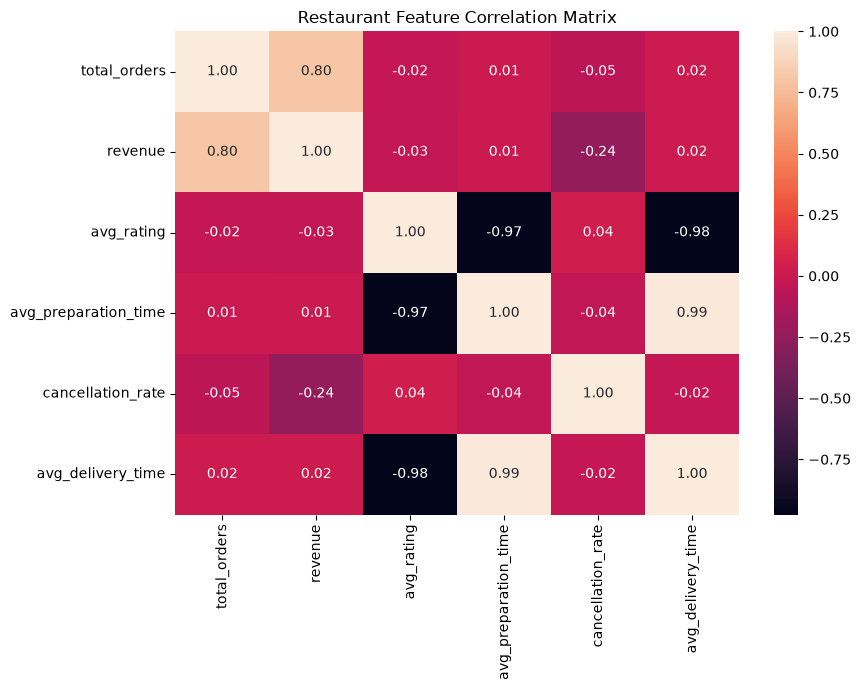

In [46]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    restaurant_features[
        restaurant_features_for_model
    ].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Restaurant Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [47]:
customer_scaler = StandardScaler()
X_customer_scaled = customer_scaler.fit_transform(X_customer)

In [48]:
restaurant_scaler = StandardScaler()
X_restaurant_scaled = restaurant_scaler.fit_transform(X_restaurant)

In [49]:
pd.DataFrame(
    X_restaurant_scaled,
    columns=restaurant_features_for_model
).describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,500.00,-0.00,1.00,-2.62,-0.75,0.07,0.75,3.22
revenue,500.00,0.00,1.00,-2.43,-0.72,-0.04,0.73,2.88
avg_rating,500.00,0.00,1.00,-2.36,-0.83,0.10,0.84,2.08
avg_preparation_time,500.00,-0.00,1.00,-1.59,-0.88,-0.07,0.91,1.89
cancellation_rate,500.00,-0.00,1.00,-2.90,-0.64,-0.03,0.59,2.85
avg_delivery_time,500.00,0.00,1.00,-1.83,-0.87,-0.08,0.84,2.13


In [50]:
restaurant_features[
    restaurant_features_for_model
].corr().round(2)

,total_orders,revenue,avg_rating,avg_preparation_time,cancellation_rate,avg_delivery_time
total_orders,1.00,0.80,-0.02,0.01,-0.05,0.02
revenue,0.80,1.00,-0.03,0.01,-0.24,0.02
avg_rating,-0.02,-0.03,1.00,-0.97,0.04,-0.98
avg_preparation_time,0.01,0.01,-0.97,1.00,-0.04,0.99
cancellation_rate,-0.05,-0.24,0.04,-0.04,1.00,-0.02
avg_delivery_time,0.02,0.02,-0.98,0.99,-0.02,1.00


In [51]:
restaurant_features_for_model = [
    "total_orders",
    "revenue",
    "avg_rating",
    "avg_preparation_time",
    "cancellation_rate"
]
X_restaurant = restaurant_features[
    restaurant_features_for_model
].copy()

restaurant_scaler = StandardScaler()

X_restaurant_scaled = restaurant_scaler.fit_transform(
    X_restaurant
)

X_restaurant_scaled = pd.DataFrame(
    X_restaurant_scaled,
    columns=restaurant_features_for_model,
    index=X_restaurant.index
)

X_restaurant_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,500.00,-0.00,1.00,-2.62,-0.75,0.07,0.75,3.22
revenue,500.00,0.00,1.00,-2.43,-0.72,-0.04,0.73,2.88
avg_rating,500.00,0.00,1.00,-2.36,-0.83,0.10,0.84,2.08
avg_preparation_time,500.00,-0.00,1.00,-1.59,-0.88,-0.07,0.91,1.89
cancellation_rate,500.00,-0.00,1.00,-2.90,-0.64,-0.03,0.59,2.85


# K Means segmentation


In [52]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

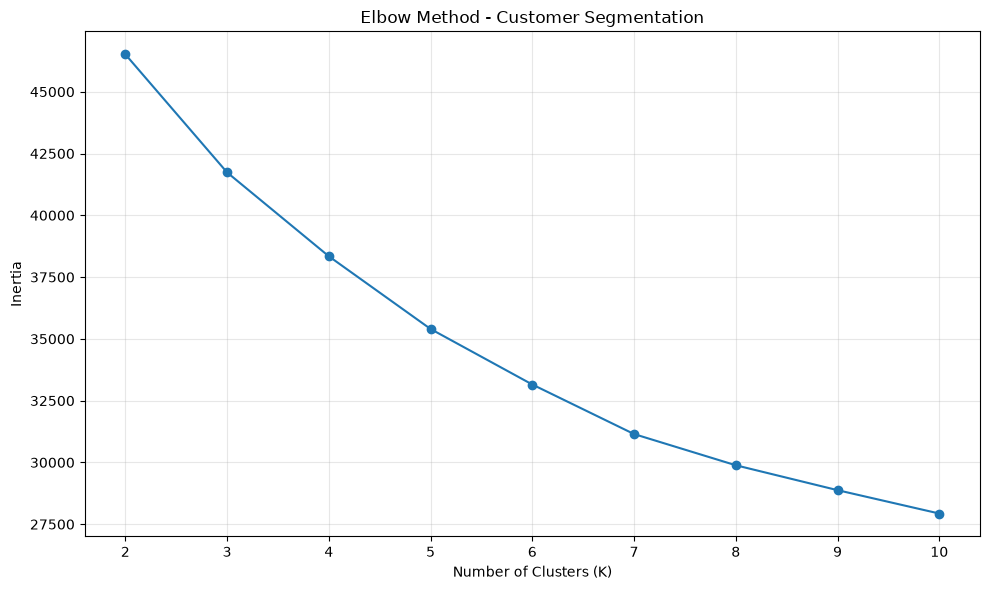

In [53]:
inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_customer_scaled)
    
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Customer Segmentation")

plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_customer_scaled)
    
    score = silhouette_score(
        X_customer_scaled,
        labels
    )
    
    silhouette_scores.append(score)

In [55]:
for k, score in zip(k_values, silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.4f}")

K=2: Silhouette Score=0.2027
K=3: Silhouette Score=0.1549
K=4: Silhouette Score=0.1459
K=5: Silhouette Score=0.1393
K=6: Silhouette Score=0.1401
K=7: Silhouette Score=0.1409
K=8: Silhouette Score=0.1319
K=9: Silhouette Score=0.1271
K=10: Silhouette Score=0.1251


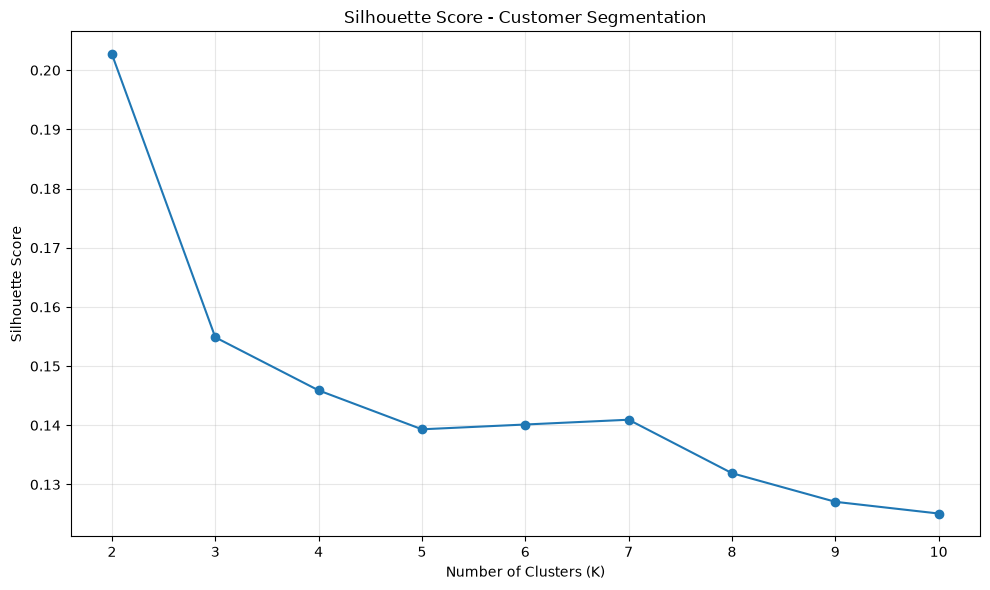

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Customer Segmentation")

plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [57]:
k_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia,
    "silhouette_score": silhouette_scores
})

k_results

,k,inertia,silhouette_score
0,2,"46,515.04",0.20
1,3,"41,736.09",0.15
2,4,"38,342.74",0.15
3,5,"35,400.41",0.14
4,6,"33,152.92",0.14
5,7,"31,147.89",0.14
6,8,"29,885.26",0.13
7,9,"28,877.57",0.13
8,10,"27,932.02",0.13


In [58]:
best_k_silhouette = k_results.loc[
    k_results["silhouette_score"].idxmax(),
    "k"
]

print(
    "Best K based on silhouette:",
    best_k_silhouette
)

Best K based on silhouette: 2


In [59]:
kmeans_customer_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

customer_labels_2 = kmeans_customer_2.fit_predict(
    X_customer_scaled
)

customer_clustered = customer_features.copy()

customer_clustered["cluster_2"] = customer_labels_2

customer_clustered["cluster_2"].value_counts().sort_index()

cluster_2
0    5691
1    4309
Name: count, dtype: int64

In [60]:
customer_profile_2 = (
    customer_clustered
    .groupby("cluster_2")[
        [
            "total_orders",
            "avg_order_value",
            "total_spending",
            "ordering_frequency",
            "avg_rating_given",
            "weekend_orders",
            "late_night_orders"
        ]
    ]
    .mean()
    .round(2)
)

customer_profile_2

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
cluster_2,,,,,,,
0,7.18,814.79,"5,847.01",1.18,3.42,2.19,1.14
1,11.41,810.29,"9,242.79",1.40,3.41,4.29,2.36


In [61]:
cluster_size = (
    customer_clustered["cluster_2"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_size

cluster_2
0   56.91
1   43.09
Name: proportion, dtype: float64

In [62]:
kmeans_customer_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_labels_3 = kmeans_customer_3.fit_predict(
    X_customer_scaled
)

customer_clustered["cluster_3"] = customer_labels_3

customer_profile_3 = (
    customer_clustered
    .groupby("cluster_3")[
        [
            "total_orders",
            "avg_order_value",
            "total_spending",
            "ordering_frequency",
            "avg_rating_given",
            "weekend_orders",
            "late_night_orders"
        ]
    ]
    .mean()
    .round(2)
)

customer_profile_3

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
cluster_3,,,,,,,
0,7.47,681.61,"5,137.09",1.19,3.53,2.38,1.22
1,7.38,971.01,"7,128.37",1.19,3.31,2.26,1.17
2,11.73,809.11,"9,490.45",1.42,3.41,4.43,2.48


In [63]:
customer_clustered["cluster_3"].value_counts().sort_index()

cluster_3
0    3421
1    2925
2    3654
Name: count, dtype: int64

In [64]:
from sklearn.cluster import KMeans

final_customer_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_clusters = final_customer_kmeans.fit_predict(
    X_customer_scaled
)

customer_segmented = customer_features.copy()

customer_segmented["cluster"] = customer_clusters

customer_segmented["cluster"].value_counts().sort_index()

cluster
0    3421
1    2925
2    3654
Name: count, dtype: int64

In [65]:
cluster_names = {
    0: "Budget Occasional Customers",
    1: "Premium Basket Customers",
    2: "Frequent High-Value Customers"
}

customer_segmented["customer_segment"] = (
    customer_segmented["cluster"]
    .map(cluster_names)
)

customer_segmented[
    [
        "customer_id",
        "cluster",
        "customer_segment"
    ]
].head(10)

,customer_id,cluster,customer_segment
0,C000001,2,Frequent High-Value Customers
1,C000002,0,Budget Occasional Customers
2,C000003,0,Budget Occasional Customers
3,C000004,2,Frequent High-Value Customers
4,C000005,0,Budget Occasional Customers
5,C000006,2,Frequent High-Value Customers
6,C000007,1,Premium Basket Customers
7,C000008,1,Premium Basket Customers
8,C000009,0,Budget Occasional Customers
9,C000010,1,Premium Basket Customers


In [66]:
customer_cluster_profile = (
    customer_segmented
    .groupby(["cluster", "customer_segment"])
    [
        [
            "total_orders",
            "avg_order_value",
            "total_spending",
            "ordering_frequency",
            "avg_rating_given",
            "weekend_orders",
            "late_night_orders"
        ]
    ]
    .mean()
    .round(2)
)

cluster_counts = (
    customer_segmented
    .groupby(["cluster", "customer_segment"])
    .size()
    .reset_index(name="customer_count")
)

cluster_counts["percentage"] = (
    cluster_counts["customer_count"]
    / len(customer_segmented)
    * 100
).round(2)

In [67]:
customer_segmented.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

customer_cluster_profile.to_csv(
    "../data/processed/customer_cluster_profile.csv"
)

# PCA for customers Kmeans


Explained variance ratio: [0.35317383 0.16721163]
Total explained variance: 0.5203854532971262


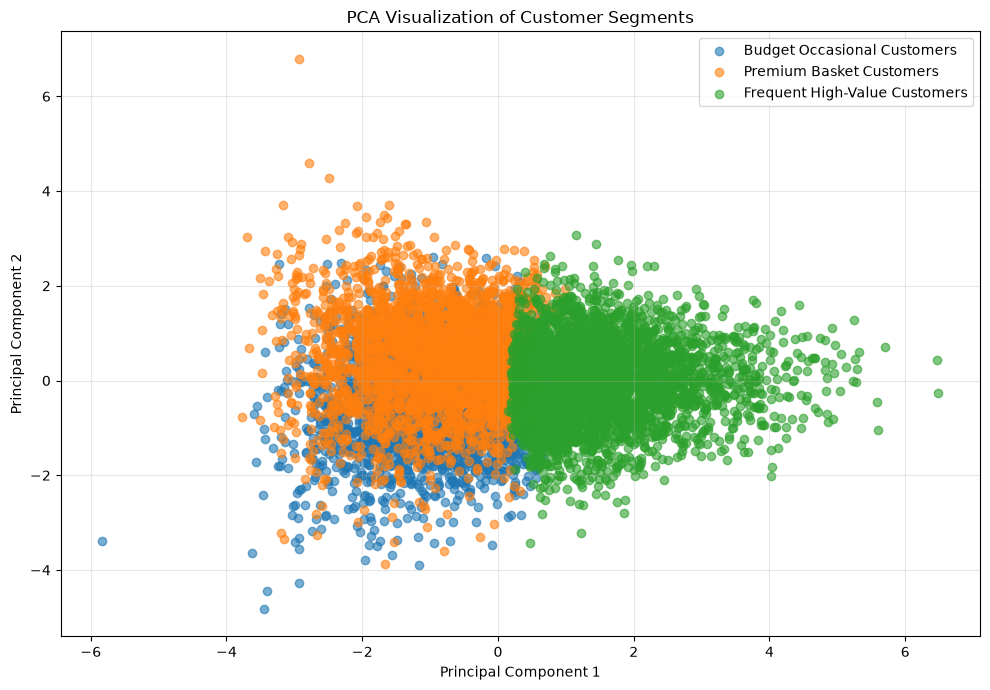

In [68]:
from sklearn.decomposition import PCA

pca_customer = PCA(
    n_components=2,
    random_state=42
)

X_customer_pca = pca_customer.fit_transform(
    X_customer_scaled
)

customer_pca_df = pd.DataFrame(
    X_customer_pca,
    columns=["PC1", "PC2"]
)

customer_pca_df["cluster"] = customer_clusters

customer_pca_df["customer_segment"] = (
    customer_pca_df["cluster"]
    .map(cluster_names)
)

print(
    "Explained variance ratio:",
    pca_customer.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca_customer.explained_variance_ratio_.sum()
)

plt.figure(figsize=(10, 7))

for cluster in sorted(customer_pca_df["cluster"].unique()):

    cluster_data = customer_pca_df[
        customer_pca_df["cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=cluster_names[cluster],
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Customer Segments")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# DBSCAN

In [69]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

In [70]:
min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X_customer_scaled)

distances, indices = neighbors.kneighbors(
    X_customer_scaled
)

In [71]:
k_distances = distances[:, -1]

k_distances = np.sort(k_distances)

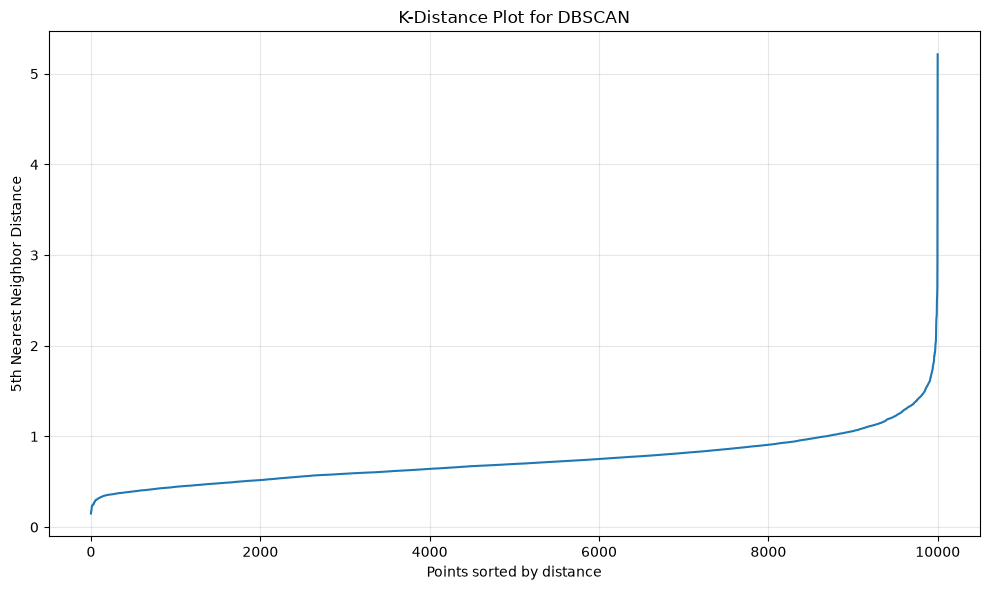

In [74]:
plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
eps_values = [
    0.5,
    0.75,
    1.0,
    1.25,
    1.5,
    1.75,
    2.0
]

In [77]:
dbscan = DBSCAN(
    eps=1,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_customer_scaled
)

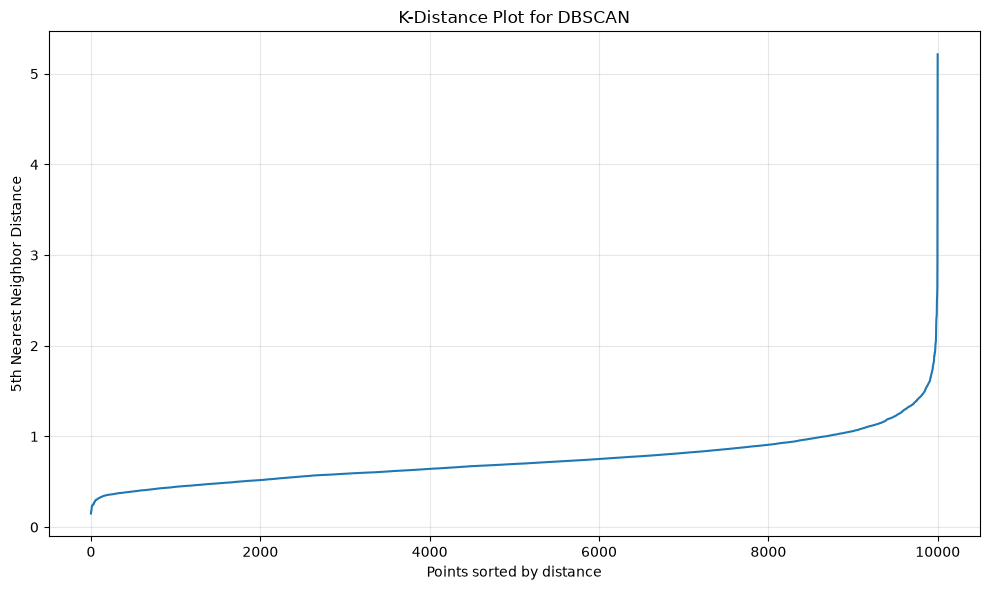

In [78]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X_customer_scaled)

distances, indices = neighbors.kneighbors(
    X_customer_scaled
)

k_distances = distances[:, -1]
k_distances = np.sort(k_distances)

plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [79]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

eps_values = [1.25, 1.50, 1.75]

dbscan_results = []

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_customer_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    n_noise = np.sum(labels == -1)

    noise_percentage = (
        n_noise / len(labels) * 100
    )

    # Silhouette requires at least 2 clusters
    # and excludes DBSCAN noise points
    non_noise_mask = labels != -1

    if (
        n_clusters >= 2
        and non_noise_mask.sum() > n_clusters
    ):
        silhouette = silhouette_score(
            X_customer_scaled[non_noise_mask],
            labels[non_noise_mask]
        )
    else:
        silhouette = np.nan

    dbscan_results.append({
        "eps": eps,
        "n_clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percentage": noise_percentage,
        "silhouette_score": silhouette
    })

dbscan_results = pd.DataFrame(dbscan_results)

dbscan_results

,eps,n_clusters,noise_points,noise_percentage,silhouette_score
0,1.25,2,192,1.92,0.42
1,1.50,1,47,0.47,NaN
2,1.75,1,22,0.22,NaN


In [80]:
final_customer_dbscan = DBSCAN(
    eps=1.25,
    min_samples=5
)

customer_dbscan_labels = final_customer_dbscan.fit_predict(
    X_customer_scaled
)

In [81]:
customer_segmented["dbscan_cluster"] = (
    customer_dbscan_labels
)

In [82]:
customer_segmented[
    "dbscan_cluster"
].value_counts().sort_index()

dbscan_cluster
-1     192
 0    9803
 1       5
Name: count, dtype: int64

In [83]:
dbscan_distribution = (
    customer_segmented["dbscan_cluster"]
    .value_counts()
    .sort_index()
    .to_frame("customer_count")
)

dbscan_distribution["percentage"] = (
    dbscan_distribution["customer_count"]
    / len(customer_segmented)
    * 100
).round(2)

dbscan_distribution

,customer_count,percentage
dbscan_cluster,,
-1,192,1.92
0,9803,98.03
1,5,0.05


In [84]:
dbscan_profile = (
    customer_segmented[
        customer_segmented["dbscan_cluster"] != -1
    ]
    .groupby("dbscan_cluster")[
        [
            "total_orders",
            "avg_order_value",
            "total_spending",
            "ordering_frequency",
            "avg_rating_given",
            "weekend_orders",
            "late_night_orders"
        ]
    ]
    .mean()
    .round(2)
)

dbscan_profile

,total_orders,avg_order_value,total_spending,ordering_frequency,avg_rating_given,weekend_orders,late_night_orders
dbscan_cluster,,,,,,,
0,8.98,812.07,"7,284.91",1.27,3.42,3.08,1.65
1,2.40,874.49,"2,100.24",1.00,1.00,1.00,0.80


In [85]:
dbscan_noise_profile = (
    customer_segmented[
        customer_segmented["dbscan_cluster"] == -1
    ][
        [
            "total_orders",
            "avg_order_value",
            "total_spending",
            "ordering_frequency",
            "avg_rating_given",
            "weekend_orders",
            "late_night_orders"
        ]
    ]
    .mean()
    .round(2)
)

dbscan_noise_profile

total_orders            10.42
avg_order_value        850.89
total_spending       8,739.93
ordering_frequency       1.63
avg_rating_given         3.26
weekend_orders           3.74
late_night_orders        2.58
dtype: float64

In [86]:
dbscan_pca_df = pd.DataFrame(
    X_customer_pca,
    columns=["PC1", "PC2"]
)

dbscan_pca_df["dbscan_cluster"] = (
    customer_dbscan_labels
)

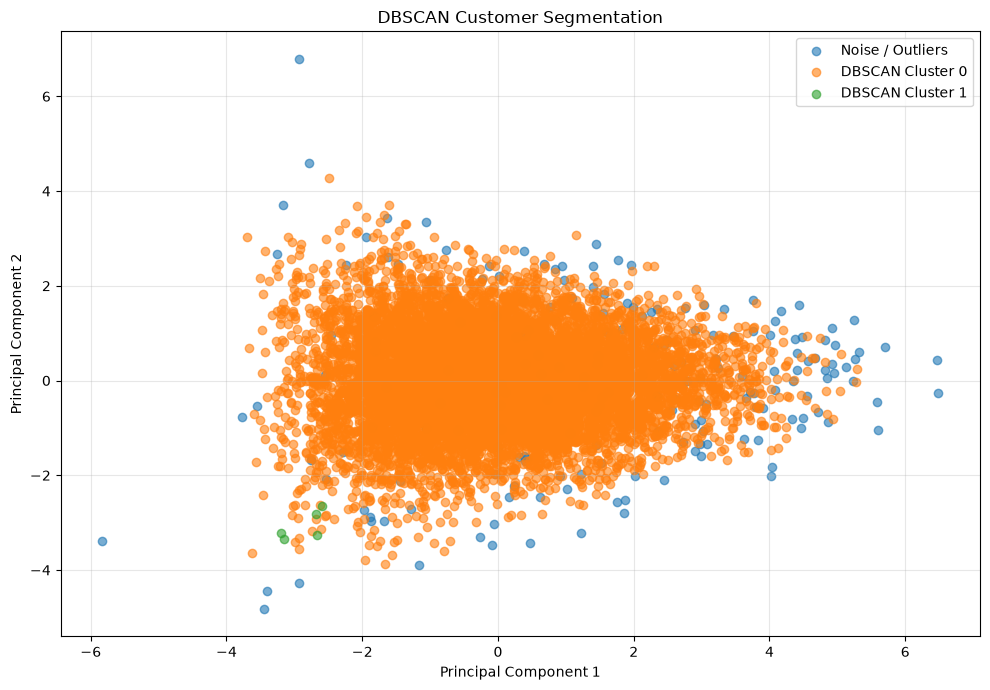

In [87]:
plt.figure(figsize=(10, 7))

for cluster in sorted(
    dbscan_pca_df["dbscan_cluster"].unique()
):

    cluster_data = dbscan_pca_df[
        dbscan_pca_df["dbscan_cluster"] == cluster
    ]

    if cluster == -1:
        label = "Noise / Outliers"
    else:
        label = f"DBSCAN Cluster {cluster}"

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=label,
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Customer Segmentation")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [88]:
customer_segmented.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)
dbscan_profile.to_csv(
    "../data/processed/customer_dbscan_profile.csv"
)